### Redes neuronales - Clasificación


In [164]:
#Bloque de imports:

import numpy as np
import pandas as pd
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.utils import to_categorical
from keras.layers import BatchNormalization
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, train_test_split

plt.rcParams['figure.figsize'] = [3, 3]

In [163]:
#Bloque de funciones:


# Cargar dataset y dividir en train / test
def cargar_dataset():
    dataset = np.loadtxt('../dataset/dataset.csv', delimiter=',', dtype=str)
    datos = dataset[:, :512].astype('float32')
    etiquetas = np.array([
        {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
        for etiqueta in dataset[:, 512]
    ])

    trainX, testX, trainY, testY = train_test_split(
        datos,
        etiquetas,
        test_size=0.2,
        random_state=1,
        stratify=etiquetas
    )

    # Clasificación de target en one-hot
    trainY = to_categorical(trainY, num_classes=5)
    testY = to_categorical(testY, num_classes=5)
    return trainX, trainY, testX, testY

# Normalización de tonos de pixel
def prep_pixels(train, test):
    # Transformar integers en floats
    train_norm = train.astype('float32')
    test_norm = test.astype('float32')
    # Normalizar 0-1
    train_norm = train_norm / 255.0
    test_norm = test_norm / 255.0
    # Devolver normalizado
    return train_norm, test_norm

# Agregar estadísticas globales y locales de los 512 bytes
def enriquecer_features(datos):
    bytes_originales = np.clip(np.rint(datos * 255), 0, 255).astype('uint8')
    histogramas = np.array([
        np.bincount(fila, minlength=256) / 512.0
        for fila in bytes_originales
    ])

    estadisticas = np.column_stack([
        bytes_originales.mean(axis=1) / 255.0,
        bytes_originales.std(axis=1) / 255.0,
        bytes_originales.min(axis=1) / 255.0,
        bytes_originales.max(axis=1) / 255.0
    ])

    bloques = bytes_originales.reshape(-1, 8, 64)
    histogramas_bloques = np.array([
        np.concatenate([
            np.bincount(bloque, minlength=256) / 64.0
            for bloque in muestra
        ])
        for muestra in bloques
    ])

    return np.concatenate([
        datos,
        histogramas,
        estadisticas,
        histogramas_bloques
    ], axis=1)


# Graficar un dígito
def graficar_uno(valor, conjunto, prediccion=None):
    fig = plt.figure
    plt.plot(conjunto[valor])
    if np.array_equiv(conjunto, trainX):
        plt.xlabel('Label train: {}'.format(np.argmax(trainY[valor])))
    if np.array_equiv(conjunto, testX):
        plt.xlabel('Label test: {}'.format(np.argmax(testY[valor])))
    if prediccion is not None:
        plt.ylabel('Predicho: '+str(prediccion))
    return plt.show()

In [165]:
# Evaluador SIMPLE

def evaluar_modelo_simple(dataX,dataY,modelo,estadoaleatorio=1,epocas=10):
	scores, histories= list(),list()
	model = modelo()
	history = model.fit(trainX, trainY, epochs=epocas, batch_size=32, validation_data=(testX, testY), verbose=1)
	_, acc = model.evaluate(testX, testY, verbose=1)
	print('> %.3f' % (acc * 100.0))
	scores.append(acc)
	histories.append(history)
	return scores, histories, model

# Evaluación con k-fold cross-validation
def evaluar_modelo_kfold(dataX, dataY, modelo, n_folds=5, estadoaleatorio=1):
	scores, histories = list(), list()
	# preparar los k-fold
	kfold = KFold(n_folds, shuffle=True, random_state=estadoaleatorio)
	# Enumerar las divisiones
	for train_ix, test_ix in kfold.split(dataX):
		# definir model
		model = modelo()
		# elegir filas para train y validation
		trainX, trainY, testX, testY = dataX[train_ix], dataY[train_ix], dataX[test_ix], dataY[test_ix]
		# fitear modelo
		history = model.fit(trainX, trainY, epochs=10, batch_size=32, validation_data=(testX, testY), verbose=0)
		# evaluar modelo
		_, acc = model.evaluate(testX, testY, verbose=0)
		print('> %.3f' % (acc * 100.0))
		# guardar puntajes
		scores.append(acc)
		histories.append(history)
	return scores, histories, model

# Graficar diagnósticos
def diagnosticos(histories):
	for i in range(len(histories)):
		# graficar loss
		plt.subplot(2, 1, 1)
		plt.title('Cross Entropy Loss')
		plt.plot(histories[i].history['loss'], color='blue', label='train')
		plt.plot(histories[i].history['val_loss'], color='orange', label='test')
		# graficar accuracy
		plt.subplot(2, 1, 2)
		plt.title('Classification Accuracy')
		plt.plot(histories[i].history['accuracy'], color='blue', label='train')
		plt.plot(histories[i].history['val_accuracy'], color='orange', label='test')
	plt.show()

In [166]:
trainX, trainY, testX, testY = cargar_dataset()
trainX, testX = prep_pixels(trainX, testX)
trainX = enriquecer_features(trainX)
testX = enriquecer_features(testX)
print('Dimensiones trainX:', trainX.shape)
print('Dimensiones testX:', testX.shape)

Dimensiones trainX: (3200, 2820)
Dimensiones testX: (800, 2820)


In [167]:
def predecirparaunalista(redneuronalentrenada,conjunto=None):
    if conjunto is None:
        conjunto = testX
    puntajes = redneuronalentrenada.predict(conjunto)
    prediccion = np.zeros(len(conjunto), dtype=int)
    for x in range(len(conjunto)):
        prediccion[x] = np.argmax(puntajes[x])
    unique, counts = np.unique(prediccion,return_counts=True)
    return dict(zip(unique,counts))

def matrizdeconfusion(redneuronalentrenada,conjunto=None, targetsonehot=None, normalizar=False):
    if conjunto is None:
        conjunto = testX
    if targetsonehot is None:
        targetsonehot = testY

    puntajes = redneuronalentrenada.predict(conjunto, verbose=0)
    prediccion = np.argmax(puntajes, axis=1)
    objetivo = np.argmax(targetsonehot, axis=1)
    etiquetas = ['gif', 'jpg', 'png', 'qoi', 'webp']

    matriz = confusion_matrix(
        objetivo,
        prediccion,
        normalize='true' if normalizar else None
    )
    display = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=etiquetas
    )
    display.plot(cmap='Blues', values_format='.2f' if normalizar else 'd')
    plt.title('Matriz de confusión')
    plt.show()


def find_non_equal_indices(list1, list2):
    non_equal_indices = []
    for i in range(min(len(list1), len(list2))):
        if list1[i] != list2[i]:
            non_equal_indices.append(i)
    return non_equal_indices

def listarerrores(adivinado,objetivo=testY):
    errores = find_non_equal_indices(adivinado,np.argmax(objetivo, axis = 1))
    return errores

In [168]:
print ("Tamaño de conjunto de entrenamiento: "+str(len(trainX)) + "\n"+"Tamaño de conjunto de test:          "+str(len(testX)))

Tamaño de conjunto de entrenamiento: 3200
Tamaño de conjunto de test:          800


In [169]:
plt.rcParams['figure.figsize'] = [3, 3]

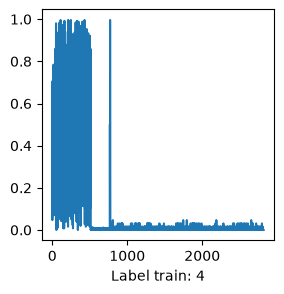

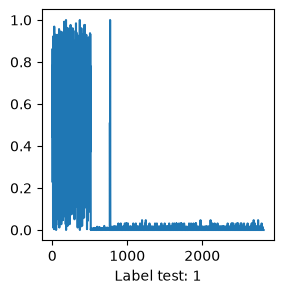

In [170]:
graficar_uno(315, trainX)
graficar_uno(100, testX)

In [172]:
# Modelo base para clasificación

def definir_modelo():
    modelo = Sequential([
        keras.Input(shape=(2820,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(5, activation='softmax')
    ])

    modelo.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return modelo

Epoch 1/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5000 - loss: 1.2989 - val_accuracy: 0.3137 - val_loss: 1.6367 - learning_rate: 0.0010
Epoch 2/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7166 - loss: 0.6823 - val_accuracy: 0.5412 - val_loss: 0.9477 - learning_rate: 0.0010
Epoch 3/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8066 - loss: 0.4865 - val_accuracy: 0.6275 - val_loss: 0.7750 - learning_rate: 0.0010
Epoch 4/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8525 - loss: 0.3819 - val_accuracy: 0.6338 - val_loss: 0.8053 - learning_rate: 0.0010
Epoch 5/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8978 - loss: 0.2951 - val_accuracy: 0.6463 - val_loss: 0.9186 - learning_rate: 0.0010
Epoch 6/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9109 - loss: 0.2482 - val_accuracy: 0.6550 - val_loss: 1.0174 - learning_rate: 0.0010
Epoch 7/150
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9413 - loss: 0.

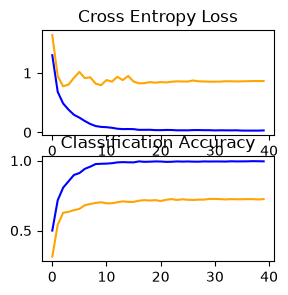

In [173]:
modelo_entrenado = definir_modelo()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=0.00001
)

# Entrenamiento y evaluación del modelo base
history = modelo_entrenado.fit(
    trainX,
    trainY,
    epochs=150,
    batch_size=32,
    validation_data=(testX, testY),
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

loss, accuracy = modelo_entrenado.evaluate(testX, testY, verbose=0)
print(f'Accuracy de validación: {accuracy * 100:.2f}%')
print("Épocas ejecutadas:", len(history.history["loss"]))
print("Mejor época:", np.argmin(history.history["val_loss"]) + 1)

diagnosticos([history])

In [174]:
# Evaluación en test_publico.csv
publico = np.loadtxt('../dataset/test_publico.csv', delimiter=',', dtype=str)
publicoX = publico[:, :512].astype('float32') / 255.0
publicoX = enriquecer_features(publicoX)
publicoY = np.array([
    {'gif': 0, 'jpg': 1, 'png': 2, 'qoi': 3, 'webp': 4}[etiqueta.strip()]
    for etiqueta in publico[:, 512]
])
publicoY = to_categorical(publicoY, num_classes=5)

publico_loss, publico_accuracy = modelo_entrenado.evaluate(
    publicoX,
    publicoY,
    verbose=0
)
print(f'Accuracy en test_publico: {publico_accuracy * 100:.2f}%')

print("Mejor train:",
      max(history.history["accuracy"]) * 100)

print("Mejor validación:",
      max(history.history["val_accuracy"]) * 100)

print("Test público:",
      publico_accuracy * 100)

Accuracy en test_publico: 67.40%
Mejor train: 99.62499737739563
Mejor validación: 72.62499928474426
Test público: 67.40000247955322


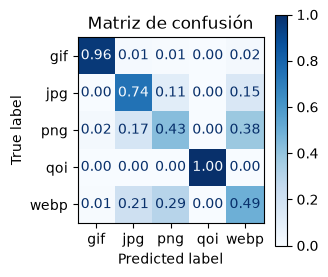

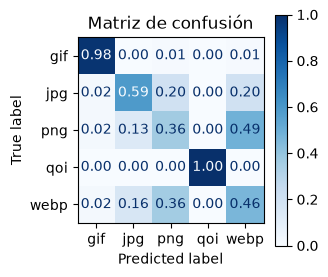

In [175]:
# Matriz de confusión sobre el conjunto de validación
matrizdeconfusion(modelo_entrenado, testX, testY, normalizar=True)

matrizdeconfusion(modelo_entrenado, publicoX,publicoY, normalizar=True)



In [ ]:
# Cargar el conjunto final sin etiquetas
test_features = np.loadtxt(
    '../dataset/clasificacion_test_features.csv',
    delimiter=',',
    dtype='float32'
) / 255.0
test_features = enriquecer_features(test_features)

print('Dimensiones de test_features:', test_features.shape)

clases = ['gif', 'jpg', 'png', 'qoi', 'webp']

probas = modelo_entrenado.predict(test_features)
predicciones = [clases[i] for i in np.argmax(probas, axis=1)]

pd.DataFrame({
    'y_pred': predicciones
}).to_csv('entrega_clasificacion.csv', index=False)

Dimensiones de test_features: (500, 512)
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step
